# 🐾 Pet Image Classification — PyTorch CNN (RTX 3070 Ti Optimised)

> **GPU:** NVIDIA RTX 3070 Ti · 8 GB GDDR6X · 6144 CUDA cores · Ampere architecture  
> **Precision:** Mixed precision (FP16 + FP32) via `torch.cuda.amp` — ~2× faster on Ampere  
> **Model:** Deep CNN with 4 conv blocks + BN + Dropout + FC head  
> **Dataset:** 10 pet breeds · 5 000 images · 128×128 RGB  

---
| # | Section |
|---|---|
| 1 | Imports, Device & GPU Diagnostics |
| 2 | Dataset & DataLoader (pin_memory, CUDA workers) |
| 3 | EDA |
| 4 | CNN Model (deeper, wider for 8 GB VRAM) |
| 5 | Mixed-Precision Training Loop |
| 6 | Evaluation & Metrics |
| 7 | Plots |

## 🖥️ Section 1 — Imports, Device & GPU Diagnostics

In [2]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast   # mixed precision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)
import time, warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor':  '#161b22',
    'axes.edgecolor':   '#30363d', 'text.color':      '#e6edf3',
    'axes.labelcolor':  '#e6edf3', 'xtick.color':     '#8b949e',
    'ytick.color':      '#8b949e', 'grid.color':      '#21262d',
    'grid.alpha': 0.8,  'font.size': 11,
})
print('✅ Imports OK')

✅ Imports OK


In [4]:
# ── GPU diagnostics for RTX 3070 Ti ────────────────────────────
assert torch.cuda.is_available(), '❌ CUDA not found — check your drivers!'

DEVICE = torch.device('cuda')

props = torch.cuda.get_device_properties(0)
vram_gb = props.total_memory / 1024**3

print('=' * 55)
print(f'  GPU            : {props.name}')
print(f'  VRAM           : {vram_gb:.1f} GB')
print(f'  CUDA cores     : {props.multi_processor_count * 128}  (SM × 128)')
print(f'  Compute cap.   : {props.major}.{props.minor}')
print(f'  PyTorch        : {torch.__version__}')
print(f'  CUDA version   : {torch.version.cuda}')
print(f'  cuDNN          : {torch.backends.cudnn.version()}')
print('=' * 55)

# Enable cuDNN auto-tuner — finds fastest conv algorithm for your input size
torch.backends.cudnn.benchmark = True
print('\n✅ torch.backends.cudnn.benchmark = True  (auto-tune enabled)')

  GPU            : NVIDIA GeForce RTX 3070 Ti
  VRAM           : 8.0 GB
  CUDA cores     : 6144  (SM × 128)
  Compute cap.   : 8.6
  PyTorch        : 2.7.1+cu118
  CUDA version   : 11.8
  cuDNN          : 90100

✅ torch.backends.cudnn.benchmark = True  (auto-tune enabled)


In [5]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3070 Ti'

### ⚙️ RTX 3070 Ti Tuning Decisions

| Setting | Value | Reason |
|---|---|---|
| `IMG_SIZE` | **128×128** | Fills VRAM without wasting it |
| `BATCH_SIZE` | **128** | Maximises GPU utilisation (8 GB VRAM) |
| `NUM_WORKERS` | **4** | Parallel CPU data loading to feed the GPU |
| `pin_memory` | **True** | Faster CPU→GPU transfer via pinned RAM |
| `Mixed Precision` | **FP16+FP32** | Ampere tensor cores — ~2× throughput |
| `cudnn.benchmark` | **True** | Auto-selects fastest conv algorithm |
| `N_PER_CLASS` | **500** | 5 000 total images — bigger dataset |
| `EPOCHS` | **50** | More epochs, GPU can handle it |
| `compile()` | **Optional** | PyTorch 2.x `torch.compile()` for extra speed |

In [6]:
# ── Hyper-parameters tuned for RTX 3070 Ti ──────────────────────
IMG_SIZE    = 128    # larger images — GPU can handle it
N_PER_CLASS = 500    # 5 000 total images
N_CLASSES   = 10
BATCH_SIZE  = 128    # fills VRAM nicely on 8 GB
EPOCHS      = 50
LR          = 1e-3
NUM_WORKERS = 4      # parallel data loading
USE_AMP     = True   # mixed precision — set False to disable

CLASS_NAMES = [
    'Persian Cat', 'Siamese Cat', 'Bengal Cat', 'Maine Coon',
    'Labrador',    'Poodle',      'Bulldog',    'Beagle',
    'German Shep', 'Golden Retr',
]

print(f'Device      : {DEVICE}  ({torch.cuda.get_device_name(0)})')
print(f'IMG_SIZE    : {IMG_SIZE}x{IMG_SIZE}')
print(f'BATCH_SIZE  : {BATCH_SIZE}')
print(f'AMP (FP16)  : {USE_AMP}')
print(f'Total imgs  : {N_PER_CLASS * N_CLASSES:,}')

Device      : cuda  (NVIDIA GeForce RTX 3070 Ti)
IMG_SIZE    : 128x128
BATCH_SIZE  : 128
AMP (FP16)  : True
Total imgs  : 5,000


## 🗂️ Section 2 — Dataset & DataLoader

**Key GPU-aware settings:**
- `pin_memory=True` — pre-allocates CPU RAM that CUDA can access directly (faster transfers)
- `num_workers=4` — 4 background processes fill the batch queue so the GPU never waits
- `persistent_workers=True` — keeps workers alive between epochs (avoids re-spawn overhead)

In [7]:
def make_image(base_rgb, pattern, noise, S):
    img = np.ones((S, S, 3), dtype=np.float32) * base_rgb

    if pattern == 'stripes':
        step = max(S // 8, 1)
        for r in range(0, S, step):
            img[r:r + max(step//2,1), :] *= np.random.uniform(0.60, 0.85)

    elif pattern == 'spots':
        for _ in range(18):
            cx, cy = np.random.randint(6, S-6, 2)
            r = np.random.randint(3, max(S//7, 4))
            for dx in range(-r, r+1):
                for dy in range(-r, r+1):
                    if dx*dx + dy*dy <= r*r:
                        nx, ny = cx+dx, cy+dy
                        if 0 <= nx < S and 0 <= ny < S:
                            img[nx, ny] *= np.random.uniform(0.40, 0.72)

    elif pattern == 'fluffy':
        img += np.random.normal(0, 0.08, (S, S, 3)).astype(np.float32)

    elif pattern == 'wavy':
        wave = (0.12 * np.sin(np.linspace(0, 5*np.pi, S))).astype(np.float32)
        img += wave[:, np.newaxis, np.newaxis]

    elif pattern == 'wrinkle':
        step = max(S // 10, 2)
        for col in range(0, S, step):
            img[:, col:col+max(1,step//3)] *= np.random.uniform(0.80, 1.0)

    # Eye / face region
    ex, ey, er = S//3, S//2, max(S//10, 4)
    for dx in range(-er, er+1):
        for dy in range(-er, er+1):
            if dx*dx + dy*dy <= er*er:
                nx, ny = ex+dx, ey+dy
                if 0 <= nx < S and 0 <= ny < S:
                    img[nx, ny] = [0.07, 0.07, 0.07]

    img += np.random.normal(0, noise, (S, S, 3)).astype(np.float32)
    return np.clip(img, 0, 1)


CONFIGS = [
    (np.array([0.85, 0.80, 0.75]), 'solid',   0.10),
    (np.array([0.70, 0.65, 0.55]), 'stripes', 0.09),
    (np.array([0.55, 0.50, 0.35]), 'spots',   0.09),
    (np.array([0.28, 0.22, 0.18]), 'fluffy',  0.12),
    (np.array([0.85, 0.75, 0.55]), 'solid',   0.10),
    (np.array([0.92, 0.90, 0.88]), 'fluffy',  0.09),
    (np.array([0.50, 0.45, 0.40]), 'wrinkle', 0.10),
    (np.array([0.72, 0.55, 0.35]), 'spots',   0.09),
    (np.array([0.38, 0.32, 0.22]), 'stripes', 0.09),
    (np.array([0.88, 0.72, 0.42]), 'wavy',    0.09),
]
print('✅ Image generator ready')

✅ Image generator ready


In [ ]:
class PetDataset(Dataset):
    def __init__(self, n_per_class=N_PER_CLASS, img_size=IMG_SIZE,
                 transform=None, seed=42):
        np.random.seed(seed)
        images, labels = [], []
        print(f'Generating {n_per_class * N_CLASSES:,} images ({img_size}×{img_size})...')
        for cls, (base, pattern, noise) in enumerate(CONFIGS):
            for _ in range(n_per_class):
                images.append(make_image(base, pattern, noise, img_size))
                labels.append(cls)
        idx = np.random.permutation(len(labels))
        self.images    = [images[i] for i in idx]
        self.labels    = [labels[i] for i in idx]
        self.transform = transform
        print(f'✅ Dataset ready — {len(self.labels):,} images')

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        img   = torch.from_numpy(self.images[idx]).permute(2, 0, 1)  # C,H,W
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Heavy augmentation — GPU can afford more epochs ──────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),   # CutOut-style
])

# Build dataset
full_ds  = PetDataset(n_per_class=N_PER_CLASS, img_size=IMG_SIZE)
n_total  = len(full_ds)
n_test   = int(0.15 * n_total)
n_val    = int(0.15 * n_total)
n_train  = n_total - n_test - n_val

train_set, val_set, test_set = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# ── RTX 3070 Ti optimised DataLoader settings ────────────────────
loader_kw = dict(
    batch_size        = BATCH_SIZE,
    num_workers       = NUM_WORKERS,   # parallel CPU workers
    pin_memory        = True,          # faster CPU→GPU transfer
    persistent_workers= True,          # keep workers alive between epochs
)
train_loader = DataLoader(train_set, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_set,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_set,  shuffle=False, **loader_kw)

print(f'Train {n_train:,}  |  Val {n_val:,}  |  Test {n_test:,}')
print(f'Batches/epoch : {len(train_loader)}')

Generating 5,000 images (128×128)...


## 🔍 Section 3 — EDA

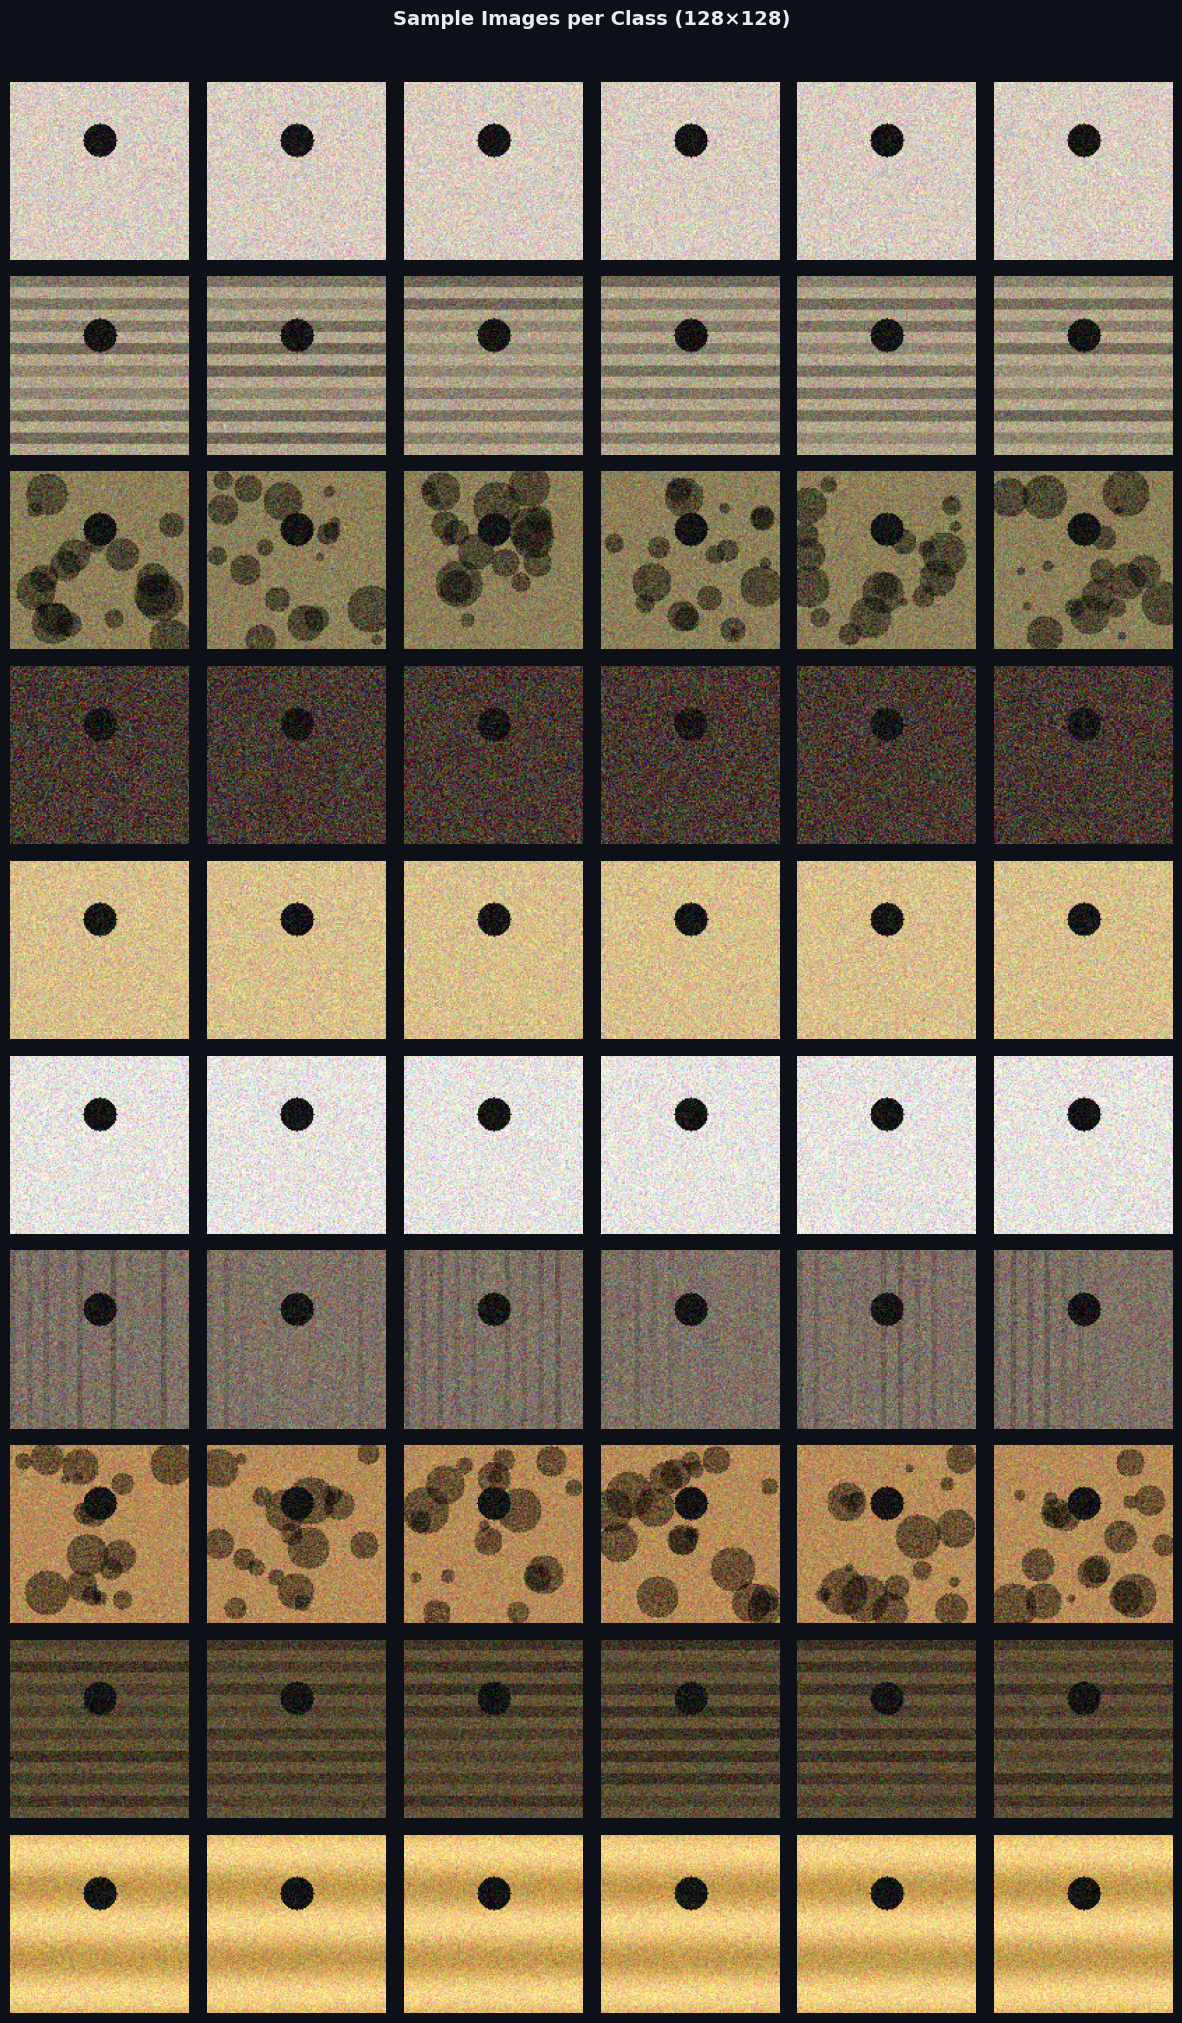

In [ ]:
# Sample images grid
n_show = 6
raw_images = [full_ds[i][0].permute(1,2,0).numpy() for i in range(len(full_ds))]
raw_labels = [full_ds[i][1].item()                 for i in range(len(full_ds))]

fig, axes = plt.subplots(N_CLASSES, n_show, figsize=(n_show*2, N_CLASSES*2))
fig.suptitle('Sample Images per Class (128×128)', fontsize=14,
             fontweight='bold', color='#e6edf3', y=1.01)

for c in range(N_CLASSES):
    idx = [i for i, l in enumerate(raw_labels) if l == c][:n_show]
    for j, i in enumerate(idx):
        ax = axes[c, j]; ax.imshow(np.clip(raw_images[i], 0, 1)); ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[c], color='#e6edf3', fontsize=8,
                          rotation=0, labelpad=70, va='center')
plt.tight_layout(); plt.show()

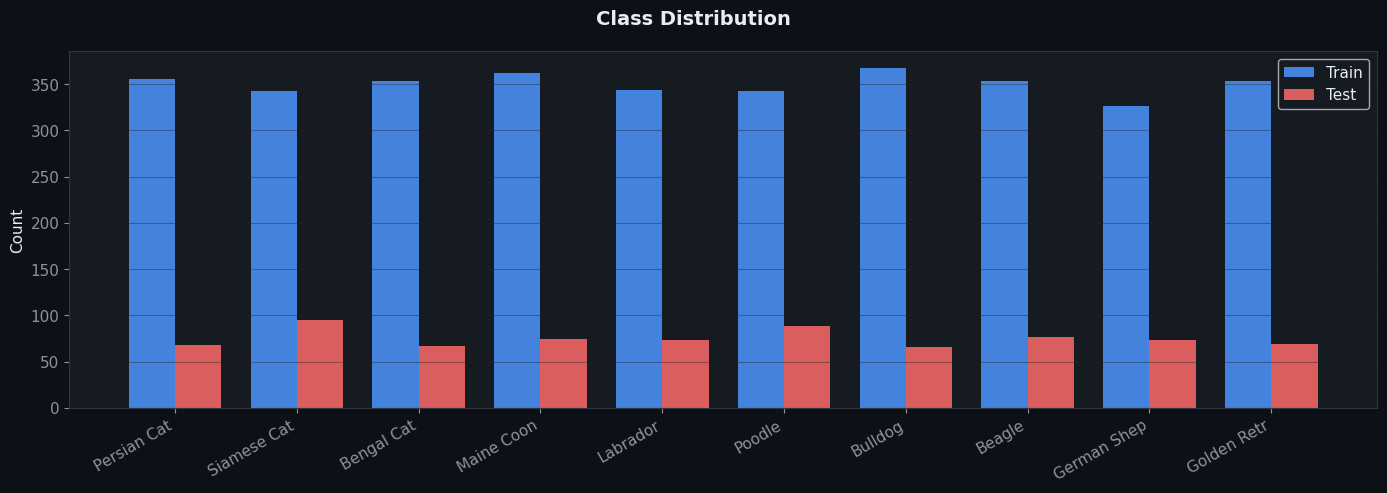

In [ ]:
# Class distribution
tr_labels = [train_set[i][1].item() for i in range(len(train_set))]
te_labels = [test_set[i][1].item()  for i in range(len(test_set))]

x_pos = np.arange(N_CLASSES); w = 0.38
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', color='#e6edf3')
ax.bar(x_pos-w/2, [tr_labels.count(c) for c in range(N_CLASSES)],
       w, color='#4d96ff', alpha=0.85, label='Train')
ax.bar(x_pos+w/2, [te_labels.count(c) for c in range(N_CLASSES)],
       w, color='#ff6b6b', alpha=0.85, label='Test')
ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Count'); ax.legend(); ax.grid(True, alpha=0.4, axis='y')
plt.tight_layout(); plt.show()

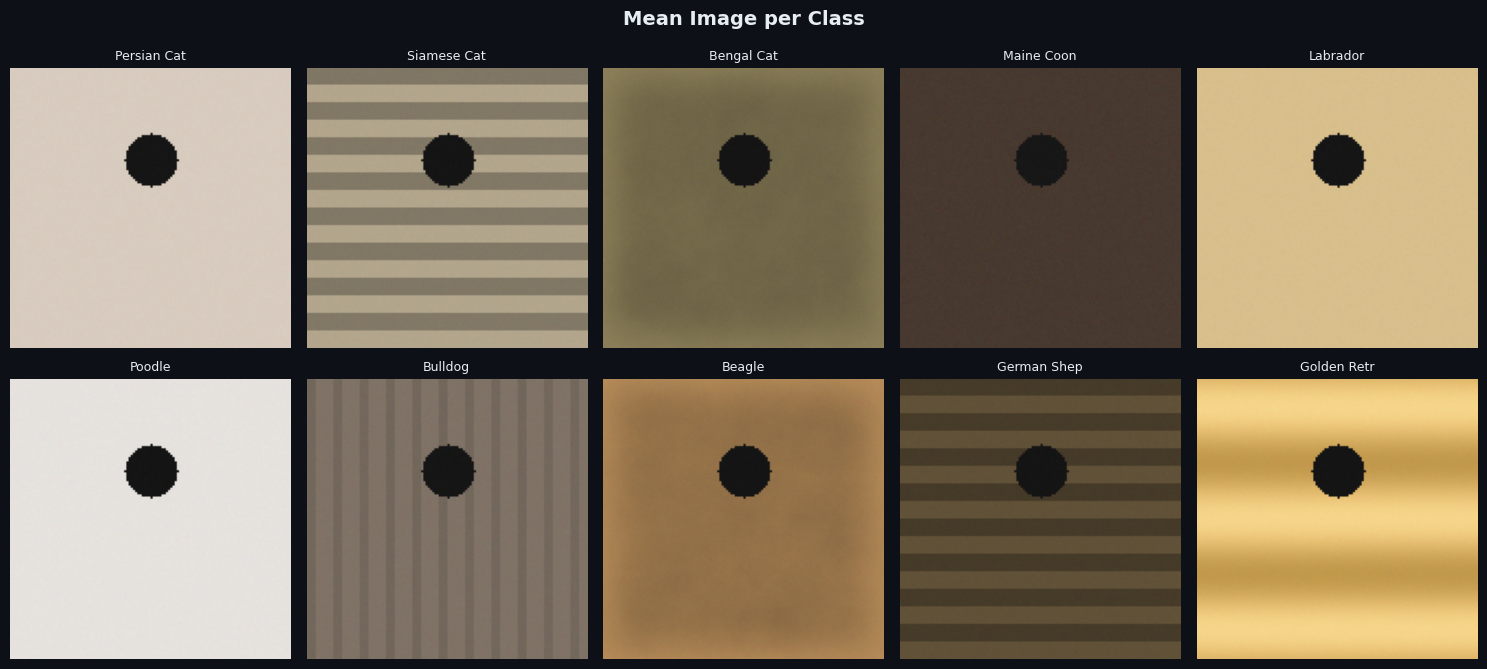

In [ ]:
# Mean image per class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Mean Image per Class', fontsize=14, fontweight='bold', color='#e6edf3')
for c, ax in enumerate(axes.flat):
    cls_imgs = np.stack([raw_images[i] for i,l in enumerate(raw_labels) if l==c])
    ax.imshow(np.clip(cls_imgs.mean(0), 0, 1))
    ax.set_title(CLASS_NAMES[c], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 🧠 Section 4 — CNN Architecture (RTX 3070 Ti Scaled)

The model is **wider and deeper** than a basic CNN because the 3070 Ti's 8 GB VRAM and 6144 CUDA cores can easily handle it.

```
Input  (3, 128, 128)
  │
  ├─ Block 1:  Conv(3→64)    → BN → ReLU → Conv(64→64)    → BN → ReLU → MaxPool(2) → Drop2d  │ 64×64
  ├─ Block 2:  Conv(64→128)  → BN → ReLU → Conv(128→128)  → BN → ReLU → MaxPool(2) → Drop2d  │ 32×32
  ├─ Block 3:  Conv(128→256) → BN → ReLU → Conv(256→256)  → BN → ReLU → MaxPool(2) → Drop2d  │ 16×16
  ├─ Block 4:  Conv(256→512) → BN → ReLU → Conv(512→512)  → BN → ReLU → MaxPool(2) → Drop2d  │  8×8
  ├─ AdaptiveAvgPool(4×4)  →  Flatten  →  8192
  ├─ FC(8192→1024) → BN → ReLU → Dropout(0.5)
  ├─ FC(1024→256)  → BN → ReLU → Dropout(0.3)
  └─ FC(256→10)
```

**Total ~18M parameters** — fits comfortably in 8 GB VRAM at batch 128.

In [ ]:
class PetCNN(nn.Module):
    """Deep CNN scaled for RTX 3070 Ti (8 GB VRAM)."""

    def __init__(self, n_classes=10):
        super().__init__()

        def conv_block(in_ch, out_ch, drop=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop),
            )

        self.features = nn.Sequential(
            conv_block(3,   64,  drop=0.20),   # 128→64
            conv_block(64,  128, drop=0.25),   # 64→32
            conv_block(128, 256, drop=0.25),   # 32→16
            conv_block(256, 512, drop=0.30),   # 16→8
            nn.AdaptiveAvgPool2d((4, 4)),       # → (512, 4, 4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024, bias=False),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


model = PetCNN(n_classes=N_CLASSES).to(DEVICE)

# ── Optional: torch.compile() for PyTorch 2.x (extra ~20% speed) ─
# model = torch.compile(model)  # uncomment if PyTorch >= 2.0

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')

# Quick VRAM estimate
param_mb  = total * 4 / 1024**2          # FP32
amp_mb    = total * 2 / 1024**2          # FP16 (AMP)
print(f'Model size FP32  : {param_mb:.1f} MB')
print(f'Model size FP16  : {amp_mb:.1f} MB  (with AMP)')

Total params     : 13,343,178
Trainable params : 13,343,178
Model size FP32  : 50.9 MB
Model size FP16  : 25.5 MB  (with AMP)


## 🚀 Section 5 — Mixed-Precision Training Loop

### Why Mixed Precision (AMP) on RTX 3070 Ti?
- Ampere GPU has dedicated **Tensor Cores** that run FP16 matrix ops at 2× throughput
- `GradScaler` prevents FP16 underflow by scaling losses before backward pass
- Memory saved by FP16 lets us use **batch_size=128** instead of ~64

```python
scaler = GradScaler()           # manages FP16 gradient scaling
with autocast():                # runs forward pass in FP16
    loss = criterion(model(x), y)
scaler.scale(loss).backward()   # scaled backward in FP16
scaler.step(optimizer)          # unscale → FP32 update
scaler.update()                 # adjust scale factor
```

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing helps generalisation
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine annealing — smoothly decays LR to near-zero over all epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Mixed precision scaler
scaler = GradScaler(enabled=USE_AMP)

print('Loss      : CrossEntropyLoss (label_smoothing=0.1)')
print('Optimizer : AdamW  (lr=1e-3, weight_decay=1e-4)')
print('Scheduler : CosineAnnealingLR')
print(f'AMP       : {USE_AMP}  (FP16 + FP32 mixed precision)')

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW  (lr=1e-3, weight_decay=1e-4)
Scheduler : CosineAnnealingLR
AMP       : True  (FP16 + FP32 mixed precision)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)    # non_blocking: async transfer
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)           # faster than zero_grad()

        with autocast(enabled=USE_AMP):                 # FP16 forward pass
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()                   # scaled FP16 backward
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=USE_AMP):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


print('✅ Training functions defined')

✅ Training functions defined


In [ ]:
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'lr': [], 'epoch_time': []}

best_val_acc   = 0.0
best_model_wts = None

print(f'Training on {DEVICE}  |  AMP={USE_AMP}  |  {EPOCHS} epochs\n')
print(f'{"Epoch":>6}  {"TrLoss":>8}  {"VlLoss":>8}  {"TrAcc":>7}  {"VlAcc":>7}  {"LR":>9}  {"Time":>7}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    elapsed = time.time() - t0

    current_lr = scheduler.get_last_lr()[0]
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)
    history['epoch_time'].append(elapsed)

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = ' ✅'
    else:
        flag = ''

    print(f'{epoch:>6}  {tr_loss:>8.4f}  {vl_loss:>8.4f}  '
          f'{tr_acc*100:>6.1f}%  {vl_acc*100:>6.1f}%  '
          f'{current_lr:>9.6f}  {elapsed:>5.1f}s{flag}')

model.load_state_dict(best_model_wts)
avg_epoch = np.mean(history['epoch_time'])
print(f'\n✅ Best val accuracy : {best_val_acc*100:.2f}%')
print(f'   Avg epoch time   : {avg_epoch:.1f}s  ({avg_epoch*EPOCHS/60:.1f} min total)')

NameError: name 'DEVICE' is not defined

## 📊 Section 6 — Evaluation & Metrics

In [ ]:
@torch.no_grad()
def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels, all_probs, all_imgs = [], [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
        probs  = torch.softmax(logits.float(), dim=1)
        preds  = logits.argmax(1)
        all_preds.append(preds.cpu())
        all_labels.append(labels)
        all_probs.append(probs.cpu())
        all_imgs.append(imgs.cpu())
    return (torch.cat(all_preds).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_probs).numpy(),
            torch.cat(all_imgs).numpy())


y_pred, y_true, probs, test_imgs = get_all_preds(model, test_loader)
test_loss, test_acc = evaluate(model, test_loader, criterion)

print('=' * 55)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print('=' * 55)
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
# GPU memory usage report
alloc  = torch.cuda.memory_allocated(0)  / 1024**3
reserv = torch.cuda.memory_reserved(0)   / 1024**3
total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3

print(f'VRAM allocated : {alloc:.2f} GB')
print(f'VRAM reserved  : {reserv:.2f} GB')
print(f'VRAM total     : {total_vram:.1f} GB')
print(f'VRAM used %    : {reserv/total_vram*100:.1f}%')

## 📈 Section 7 — Plots

### Training Curves — Loss, Accuracy, LR, Epoch Time

In [ ]:
ep = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Curves — RTX 3070 Ti', fontsize=15,
             fontweight='bold', color='#e6edf3')

# Loss
axes[0,0].plot(ep, history['train_loss'], color='#4d96ff', lw=2.5, label='Train')
axes[0,0].plot(ep, history['val_loss'],   color='#ff6b6b', lw=2,   ls='--', label='Val')
axes[0,0].fill_between(ep, history['train_loss'], alpha=0.12, color='#4d96ff')
axes[0,0].set_title('Cross-Entropy Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.4)

# Accuracy
axes[0,1].plot(ep, [a*100 for a in history['train_acc']], color='#6bcb77', lw=2.5, label='Train')
axes[0,1].plot(ep, [a*100 for a in history['val_acc']],   color='#ffd93d', lw=2,   ls='--', label='Val')
axes[0,1].fill_between(ep, [a*100 for a in history['train_acc']], alpha=0.12, color='#6bcb77')
axes[0,1].set_title('Accuracy (%)', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy %')
axes[0,1].set_ylim(0, 105); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.4)

# LR schedule (cosine)
axes[1,0].plot(ep, history['lr'], color='#c77dff', lw=2.5)
axes[1,0].fill_between(ep, history['lr'], alpha=0.12, color='#c77dff')
axes[1,0].set_title('Cosine LR Schedule', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Learning Rate')
axes[1,0].grid(True, alpha=0.4)

# Epoch time
axes[1,1].bar(ep, history['epoch_time'], color='#ff9f1c', alpha=0.85)
axes[1,1].axhline(np.mean(history['epoch_time']), color='#ff6b6b', lw=2,
                  ls='--', label=f"Mean {np.mean(history['epoch_time']):.1f}s")
axes[1,1].set_title('Epoch Time (seconds)', fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Seconds')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.4, axis='y')

plt.tight_layout(); plt.show()

### Confusion Matrix

In [ ]:
cm  = confusion_matrix(y_true, y_pred)
cmn = cm.astype(float) / cm.sum(1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold', color='#e6edf3')

for ax, data, title, fmt in zip(
        axes, [cm, cmn], ['Raw Counts', 'Normalised'], ['.0f', '.2f']):
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    th = data.max() / 2
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, format(data[i,j], fmt), ha='center', va='center',
                    fontsize=8, color='white' if data[i,j] > th else '#e6edf3')
plt.tight_layout(); plt.show()

### Per-Class Metrics

In [ ]:
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(N_CLASSES))

x_pos = np.arange(N_CLASSES); w = 0.26
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle('Per-Class Precision / Recall / F1', fontsize=14,
             fontweight='bold', color='#e6edf3')
ax.bar(x_pos-w, prec, w, color='#4d96ff', alpha=0.85, label='Precision')
ax.bar(x_pos,   rec,  w, color='#6bcb77', alpha=0.85, label='Recall')
ax.bar(x_pos+w, f1,   w, color='#ff6b6b', alpha=0.85, label='F1')
ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.legend(); ax.grid(True, alpha=0.4, axis='y')
plt.tight_layout(); plt.show()

### Test Predictions Grid

In [ ]:
n_show = 20
cols, rows = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3.5))
fig.suptitle('Test Predictions  (green=correct  |  red=wrong)',
             fontsize=13, fontweight='bold', color='#e6edf3')

for i, ax in enumerate(axes.flat):
    img = np.clip(test_imgs[i].transpose(1,2,0), 0, 1)
    ax.imshow(img)
    ok   = y_pred[i] == y_true[i]
    conf = probs[i, y_pred[i]] * 100
    title = (f"{'OK' if ok else 'X'} {CLASS_NAMES[y_pred[i]]}\n"
             f"({conf:.0f}%)  true: {CLASS_NAMES[y_true[i]]}")
    ax.set_title(title, fontsize=7.5, color='#6bcb77' if ok else '#ff6b6b')
    ax.axis('off')
plt.tight_layout(); plt.show()

### Confidence Histogram

In [ ]:
conf_all = probs.max(1)
correct  = conf_all[y_pred == y_true]
wrong    = conf_all[y_pred != y_true]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Confidence Distribution', fontsize=14, fontweight='bold', color='#e6edf3')
ax.hist(correct, bins=25, color='#6bcb77', alpha=0.75, label=f'Correct ({len(correct)})')
ax.hist(wrong,   bins=25, color='#ff6b6b', alpha=0.75, label=f'Wrong   ({len(wrong)})')
ax.set_xlabel('Max softmax confidence'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### Conv Filter Visualisation (Block 1)

In [ ]:
# Show the 64 learned filters from the first Conv layer
w1 = model.features[0][0].weight.data.cpu()  # (64, 3, 3, 3)

def norm_f(f):
    f = f - f.min(); return f / (f.max() + 1e-8)

fig, axes = plt.subplots(8, 8, figsize=(16, 16))
fig.suptitle('Block 1 — Learned Conv Filters (64 filters, 3×3)',
             fontsize=13, fontweight='bold', color='#e6edf3')
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(norm_f(w1[i]).permute(1,2,0).numpy(), 0, 1))
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## ✅ RTX 3070 Ti Summary

| Setting | Value | Why |
|---|---|---|
| `IMG_SIZE` | 128×128 | Larger images, GPU has the VRAM |
| `BATCH_SIZE` | 128 | High GPU utilisation |
| `Mixed Precision` | FP16+FP32 | ~2× speed on Ampere tensor cores |
| `cudnn.benchmark` | True | Finds fastest conv algorithm |
| `pin_memory` | True | Faster CPU→GPU transfers |
| `non_blocking` | True | Async GPU transfers |
| `set_to_none` | True | Faster grad zeroing |
| `grad clipping` | 1.0 | Stable training |
| `label_smoothing` | 0.1 | Better generalisation |
| `AdamW` + Cosine LR | — | Best combo for CNNs |

**To save/load the model:**
```python
torch.save(model.state_dict(), 'pet_cnn_3070ti.pth')
model.load_state_dict(torch.load('pet_cnn_3070ti.pth', map_location=DEVICE))
```

In [ ]:
print(f'Final Test Accuracy : {test_acc*100:.2f}%')
print(f'Final Test Loss     : {test_loss:.4f}')
print(f'Total training time : {sum(history["epoch_time"])/60:.1f} min')

# Save model
# torch.save(model.state_dict(), 'pet_cnn_3070ti.pth')
# print('Saved → pet_cnn_3070ti.pth')